In [1]:
pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 46.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.0 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=7bc242a2ca450a5abdec991a224d65fa5365e75f3d264ada90977d5f262d5898
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pretty_midi
from tqdm import tqdm
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
input_path = Path("/content/drive/MyDrive/CSE425 Project/data/raw_data")
output_path = Path('/content/drive/MyDrive/CSE425 Project/data/train-val-test')
output_path.mkdir(parents=True, exist_ok=True)
processed_info_path = Path('/content/drive/MyDrive/CSE425 Project/data/processed_info')
processed_info_path.mkdir(parents=True, exist_ok=True)
plots_path = Path('/content/drive/MyDrive/CSE425 Project/output/EDA')
plots_path.mkdir(parents=True, exist_ok=True)

print(f"Reading from: {input_path}")
print(f"Writing to: {output_path}")
print(f"Will save config/stats to: {processed_info_path}")
midi_count = len(list(input_path.glob('**/*.mid'))) + len(list(input_path.glob('**/*.midi')))
print(f"Found {midi_count} MIDI files")

Reading from: /content/drive/MyDrive/CSE425 Project/data/raw_data
Writing to: /content/drive/MyDrive/CSE425 Project/data/train-val-test
Will save config/stats to: /content/drive/MyDrive/CSE425 Project/data/processed_info
Found 1276 MIDI files


In [5]:
#Collect statistics on the MIDI files to understand the dataset better
midi_files = sorted(list(input_path.glob('**/*.mid')) + list(input_path.glob('**/*.midi')))
print(f"Total MIDI files found: {len(midi_files)}")

# Statistics lists
durations = []
note_counts = []
pitch_histogram = np.zeros(88)  # 88 piano keys (MIDI 21-108)
velocity_histogram = []
file_stats = []

for midi_file in tqdm(midi_files[:100], desc="Analyzing MIDI files"):  # Using first 100 for speed
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_file))
        duration = pm.get_end_time()
        durations.append(duration)

        if len(pm.instruments) > 0:
            notes = pm.instruments[0].notes
            note_counts.append(len(notes))

            for note in notes:
                # Map MIDI pitch to piano key index (21-108 -> 0-87)
                if 21 <= note.pitch <= 108:
                    pitch_idx = note.pitch - 21
                    pitch_histogram[pitch_idx] += 1
                    velocity_histogram.append(note.velocity)

        file_stats.append({
            'file': midi_file.name,
            'duration': duration,
            'note_count': len(notes) if len(pm.instruments) > 0 else 0
        })
    except Exception as e:
        print(f"Error processing {midi_file}: {e}")

print(f"Successfully processed: {len(file_stats)} files")
print(f"Total notes collected: {len(velocity_histogram)}")

Total MIDI files found: 1276


Analyzing MIDI files: 100%|██████████| 100/100 [00:35<00:00,  2.81it/s]

Successfully processed: 100 files
Total notes collected: 639174


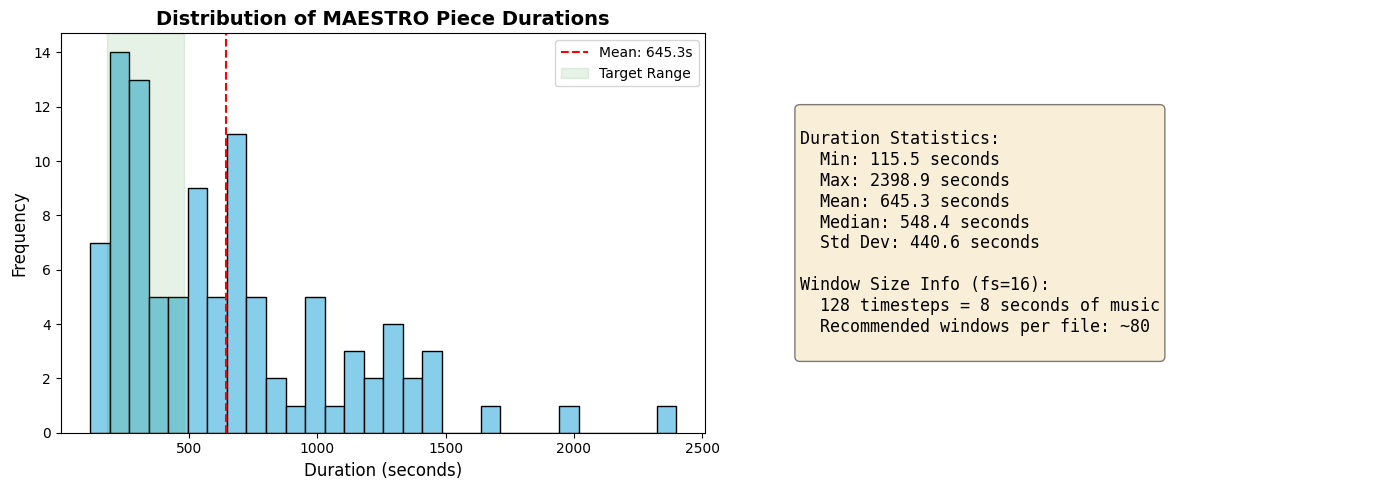

Duration range: 115.5s - 2398.9s
Mean duration: 645.3s


In [6]:
#Piece Duration Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
axes[0].hist(durations, bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Duration (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of MAESTRO Piece Durations', fontsize=14, fontweight='bold')
axes[0].axvline(np.mean(durations), color='red', linestyle='--', label=f'Mean: {np.mean(durations):.1f}s')
axes[0].axvspan(180, 480, color='green', alpha=0.1, label='Target Range')
axes[0].legend()

# Duration statistics
axes[1].axis('off')
stats_text = f"""
Duration Statistics:
  Min: {np.min(durations):.1f} seconds
  Max: {np.max(durations):.1f} seconds
  Mean: {np.mean(durations):.1f} seconds
  Median: {np.median(durations):.1f} seconds
  Std Dev: {np.std(durations):.1f} seconds

Window Size Info (fs=16):
  128 timesteps = 8 seconds of music
  Recommended windows per file: ~{int(np.mean(durations) / 8)}
"""
axes[1].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             family='monospace')

plt.tight_layout()
plt.savefig(plots_path / 'maestro_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Duration range: {np.min(durations):.1f}s - {np.max(durations):.1f}s")
print(f"Mean duration: {np.mean(durations):.1f}s")

^Window Size: 128 timesteps (8 seconds at $fs=16$).

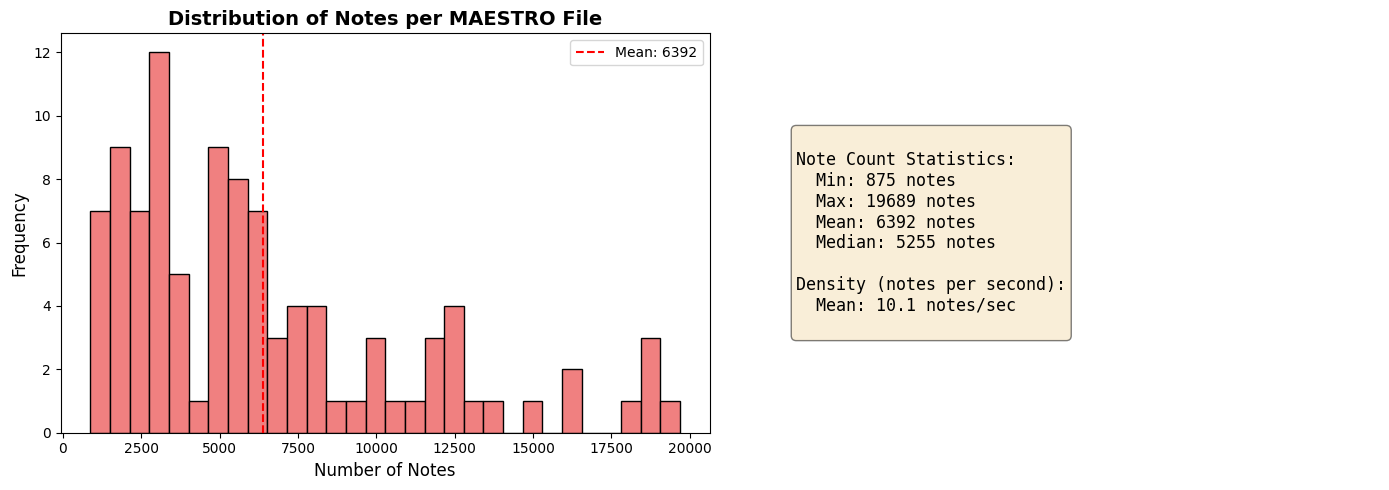

Note count range: 875 - 19689
Mean notes per file: 6392


In [7]:
#Note Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(note_counts, bins=30, color='lightcoral', edgecolor='black')
axes[0].set_xlabel('Number of Notes', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Notes per MAESTRO File', fontsize=14, fontweight='bold')
axes[0].axvline(np.mean(note_counts), color='red', linestyle='--', label=f'Mean: {np.mean(note_counts):.0f}')
axes[0].legend()

axes[1].axis('off')
stats_text = f"""
Note Count Statistics:
  Min: {np.min(note_counts):.0f} notes
  Max: {np.max(note_counts):.0f} notes
  Mean: {np.mean(note_counts):.0f} notes
  Median: {np.median(note_counts):.0f} notes

Density (notes per second):
  Mean: {np.mean(np.array(note_counts) / np.array(durations)):.1f} notes/sec
"""
axes[1].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             family='monospace')

plt.tight_layout()
plt.savefig(plots_path / 'maestro_note_count_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Note count range: {np.min(note_counts):.0f} - {np.max(note_counts):.0f}")
print(f"Mean notes per file: {np.mean(note_counts):.0f}")

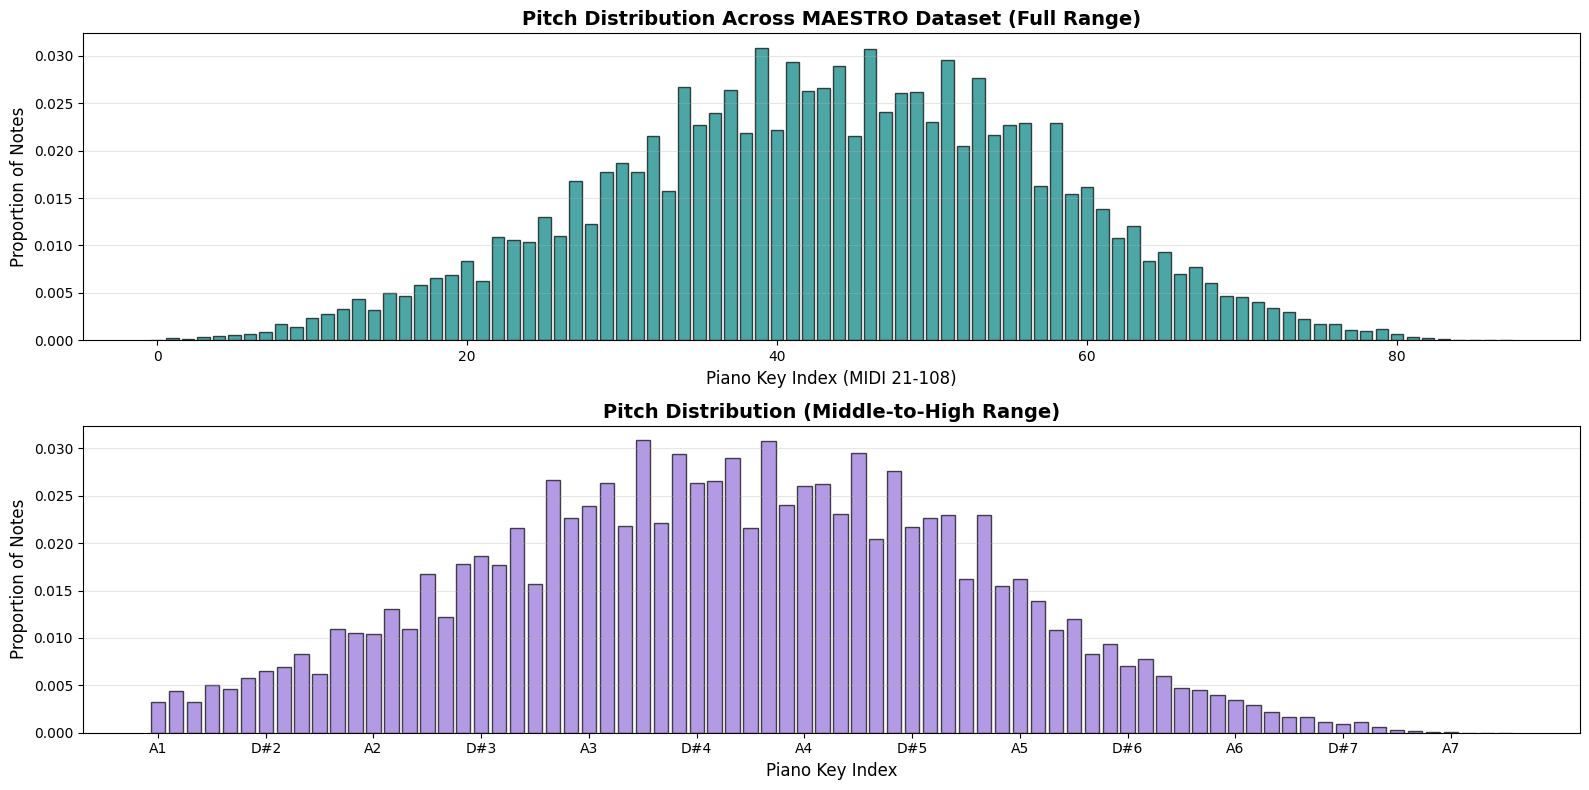

Top 5 most common pitches:
  C4 (MIDI 60): 19710 occurrences
  G4 (MIDI 67): 19662 occurrences
  C5 (MIDI 72): 18864 occurrences
  D4 (MIDI 62): 18776 occurrences
  F4 (MIDI 65): 18518 occurrences


In [8]:
# pitch histogram
pitch_histogram_norm = pitch_histogram / np.sum(pitch_histogram)

pitch_names = []
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
for i in range(88):
    pitch = i + 21  # MIDI pitch 21-108
    octave = (pitch // 12) - 1
    note = note_names[pitch % 12]
    pitch_names.append(f"{note}{octave}")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].bar(range(88), pitch_histogram_norm, color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Piano Key Index (MIDI 21-108)', fontsize=12)
axes[0].set_ylabel('Proportion of Notes', fontsize=12)
axes[0].set_title('Pitch Distribution Across MAESTRO Dataset (Full Range)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

mid_c_idx = 12  # C3
high_c_idx = 87  # C8
axes[1].bar(range(mid_c_idx, high_c_idx+1), pitch_histogram_norm[mid_c_idx:high_c_idx+1],
             color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Piano Key Index', fontsize=12)
axes[1].set_ylabel('Proportion of Notes', fontsize=12)
axes[1].set_title('Pitch Distribution (Middle-to-High Range)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(mid_c_idx, high_c_idx+1, 6))
axes[1].set_xticklabels([pitch_names[i] for i in range(mid_c_idx, high_c_idx+1, 6)])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(plots_path / 'maestro_pitch_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

top_5_idx = np.argsort(pitch_histogram)[-5:][::-1]
print("Top 5 most common pitches:")
for idx in top_5_idx:
    print(f"  {pitch_names[idx]} (MIDI {idx+21}): {pitch_histogram[idx]:.0f} occurrences")

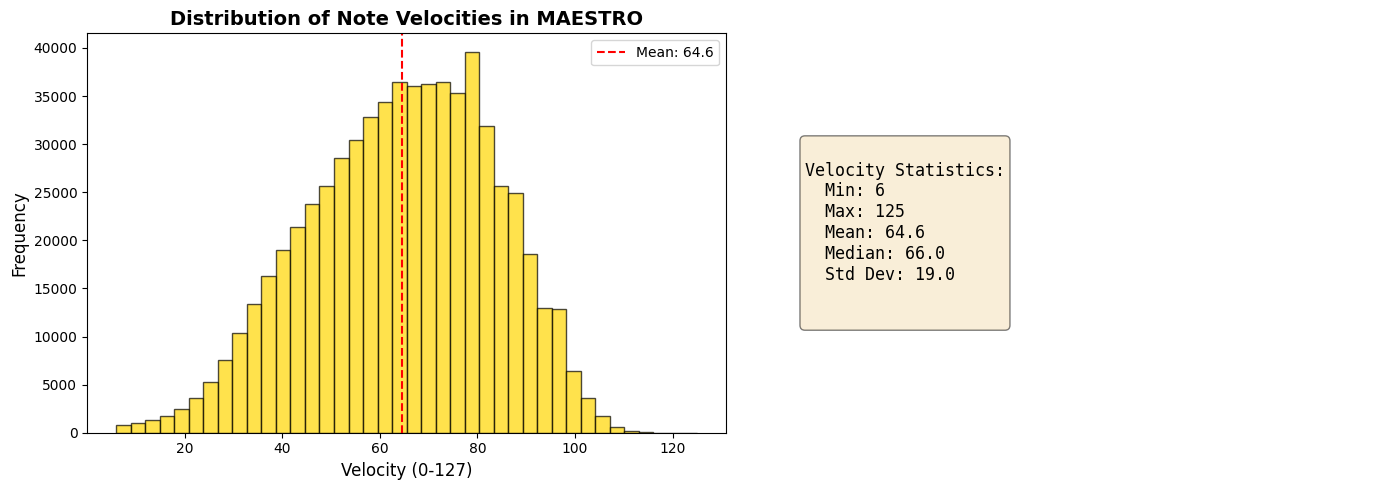

Velocity range: 6 - 125
Mean velocity: 64.6


In [9]:
#Velocity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(velocity_histogram, bins=40, color='gold', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Velocity (0-127)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Note Velocities in MAESTRO', fontsize=14, fontweight='bold')
axes[0].axvline(np.mean(velocity_histogram), color='red', linestyle='--', label=f'Mean: {np.mean(velocity_histogram):.1f}')
axes[0].legend()

axes[1].axis('off')
stats_text = f"""
Velocity Statistics:
  Min: {np.min(velocity_histogram):.0f}
  Max: {np.max(velocity_histogram):.0f}
  Mean: {np.mean(velocity_histogram):.1f}
  Median: {np.median(velocity_histogram):.1f}
  Std Dev: {np.std(velocity_histogram):.1f}

"""
axes[1].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             family='monospace')

plt.tight_layout()
plt.savefig(plots_path / 'maestro_velocity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Velocity range: {np.min(velocity_histogram):.0f} - {np.max(velocity_histogram):.0f}")
print(f"Mean velocity: {np.mean(velocity_histogram):.1f}")

^We finna binarize for task 1 and 2
retain for task 3 and 4

Computing sparsity statistics on sample MIDI files...


Sparsity analysis: 100%|██████████| 20/20 [00:08<00:00,  2.32it/s]


Total windows analyzed: 1585
Sparsity statistics: Min=59.32%, Max=100.00%, Mean=94.46%
Activity (non-zero cells) Mean: 5.54%


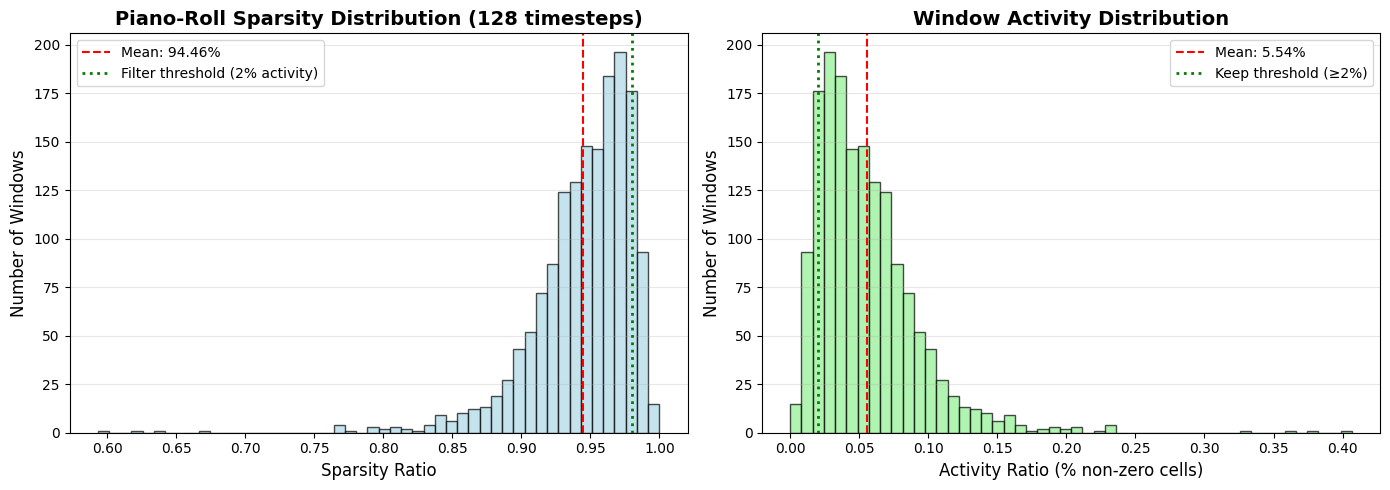


Filtering Summary (2% activity threshold):
  Total windows: 1585
  Windows to keep: 1388 (87.6%)
  Windows to discard: 197 (12.4%)


In [10]:
#Sparsity analysis
FS = 16
WINDOW_LENGTH = 128

sparsity_values = []
window_activity = []

print("Computing sparsity statistics on sample MIDI files...")
for midi_file in tqdm(midi_files[:20], desc="Sparsity analysis"):
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_file))
        piano_roll = pm.get_piano_roll(fs=FS)
        piano_roll = piano_roll[21:109, :]
        piano_roll = piano_roll.T
        piano_roll = (piano_roll > 0).astype(np.float32)
        num_windows = piano_roll.shape[0] // WINDOW_LENGTH
        for w in range(num_windows):
            window = piano_roll[w*WINDOW_LENGTH:(w+1)*WINDOW_LENGTH, :]
            num_active = np.sum(window)
            total_cells = window.size
            activity_ratio = num_active / total_cells
            sparsity = 1 - activity_ratio

            sparsity_values.append(sparsity)
            window_activity.append(activity_ratio)
    except Exception as e:
        pass

print(f"Total windows analyzed: {len(sparsity_values)}")
print(f"Sparsity statistics: Min={np.min(sparsity_values):.2%}, "
      f"Max={np.max(sparsity_values):.2%}, "
      f"Mean={np.mean(sparsity_values):.2%}")
print(f"Activity (non-zero cells) Mean: {np.mean(window_activity):.2%}")

#THE PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(sparsity_values, bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sparsity Ratio', fontsize=12)
axes[0].set_ylabel('Number of Windows', fontsize=12)
axes[0].set_title('Piano-Roll Sparsity Distribution (128 timesteps)', fontsize=14, fontweight='bold')
axes[0].axvline(np.mean(sparsity_values), color='red', linestyle='--', label=f'Mean: {np.mean(sparsity_values):.2%}')
axes[0].axvline(0.98, color='green', linestyle=':', linewidth=2, label='Filter threshold (2% activity)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[1].hist(window_activity, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Activity Ratio (% non-zero cells)', fontsize=12)
axes[1].set_ylabel('Number of Windows', fontsize=12)
axes[1].set_title('Window Activity Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(np.mean(window_activity), color='red', linestyle='--', label=f'Mean: {np.mean(window_activity):.2%}')
axes[1].axvline(0.02, color='green', linestyle=':', linewidth=2, label='Keep threshold (≥2%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(plots_path / 'maestro_sparsity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

windows_to_keep = np.sum(np.array(window_activity) >= 0.02)
total_windows = len(window_activity)
print(f"\nFiltering Summary (2% activity threshold):")
print(f"  Total windows: {total_windows}")
print(f"  Windows to keep: {windows_to_keep} ({windows_to_keep/total_windows*100:.1f}%)")
print(f"  Windows to discard: {total_windows - windows_to_keep} ({(total_windows - windows_to_keep)/total_windows*100:.1f}%)")

We neet to set a threshold, if a window has < 0.5%, we will delete if from the training set
so that our model does not learn silence